# Tokenizer accuracy: LightweightTokenizer vs count_tokens_approximately

The API server uses `LightweightTokenizer` (Qwen tokenizer.json via the Rust `tokenizers` crate)
to count prompt tokens before each LLM call — used for context-window budget decisions in `qa_graph.py`.
This costs ~94 MB at startup.

`count_tokens_approximately` (langchain_core, 4 chars/token heuristic) costs ~0 MB.

This notebook measures the error distribution across realistic message samples derived from
`meeplemate/eval/test_cases.yaml` to inform whether the approximation is accurate enough.

In [1]:
import sys
# Match API server behaviour — blocks transformers from loading
if 'transformers' not in sys.modules:
    sys.modules['transformers'] = None  # type: ignore[assignment]

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langchain_core.messages.utils import count_tokens_approximately
from meeplemate.llm_models import load_lightweight_tokenizer

MODEL_NAME = 'Qwen/Qwen3-30B-A3B-Instruct-2507'
tokenizer = load_lightweight_tokenizer(MODEL_NAME)
print('Tokenizer loaded.')

Tokenizer loaded.


In [2]:
# Load test cases
yaml_path = Path('../meeplemate/eval/test_cases.yaml')
with open(yaml_path) as f:
    groups = yaml.safe_load(f)

all_cases = []
for group in groups:
    for tc in group['test_cases']:
        all_cases.append(tc)

print(f'{len(all_cases)} test cases loaded')

33 test cases loaded


In [3]:
# Helpers

SYSTEM_PROMPT = (
    "You are a board game rules assistant. Answer questions about game rules accurately "
    "based on the provided rulebook excerpts. If the rules don't clearly address the "
    "question, say so."
)

ROLE_MAP = {'human': 'user', 'ai': 'assistant', 'system': 'system'}

def msgs_to_dicts(messages):
    """Convert LangChain messages to the dict format LightweightTokenizer expects."""
    return [{'role': ROLE_MAP.get(m.type, m.type), 'content': m.content} for m in messages]

def lightweight_count(messages):
    return len(tokenizer.apply_chat_template(
        msgs_to_dicts(messages), tokenize=True, add_generation_prompt=True
    ))

def approx_count(messages):
    return count_tokens_approximately(messages)

def format_evidence(evidence_list):
    parts = []
    for e in evidence_list:
        parts.append(f"[{e.get('rulebook', 'Rulebook')}, p.{e.get('page', '?')}]\n{e.get('quote', '').strip()}")
    return '\n\n'.join(parts)

In [4]:
# Build message samples
#
# Three shapes per test case, mirroring qa_graph.py's real prompt patterns:
#   short  — system + user query only
#   medium — system + some retrieved context + user query
#   long   — system + all evidence + user query + assistant answer (multi-turn)

samples = []

for tc in all_cases:
    query = tc['query'].strip()
    answer = tc.get('reference_answer', '').strip()
    evidence = tc.get('evidence', [])
    name = tc['name']

    # Short: system + query
    msgs_short = [
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=query),
    ]
    samples.append({'name': name, 'shape': 'short', 'messages': msgs_short})

    # Medium: system + first 2 evidence quotes as context + query
    if evidence:
        context = format_evidence(evidence[:2])
        msgs_medium = [
            SystemMessage(content=SYSTEM_PROMPT),
            HumanMessage(content=f"Relevant rules:\n{context}\n\nQuestion: {query}"),
        ]
        samples.append({'name': name, 'shape': 'medium', 'messages': msgs_medium})

    # Long: system + all evidence + query + answer (simulates a conversation turn)
    if evidence and answer:
        context = format_evidence(evidence)
        msgs_long = [
            SystemMessage(content=SYSTEM_PROMPT),
            HumanMessage(content=f"Relevant rules:\n{context}\n\nQuestion: {query}"),
            AIMessage(content=answer),
        ]
        samples.append({'name': name, 'shape': 'long', 'messages': msgs_long})

print(f'{len(samples)} samples built ({len(all_cases)} test cases × up to 3 shapes)')

93 samples built (33 test cases × up to 3 shapes)


In [5]:
# Count tokens with both methods
rows = []
for s in samples:
    lw = lightweight_count(s['messages'])
    ap = approx_count(s['messages'])
    delta = ap - lw
    pct = delta / lw * 100 if lw > 0 else float('nan')
    rows.append({
        'name': s['name'],
        'shape': s['shape'],
        'lightweight': lw,
        'approx': ap,
        'delta': delta,
        'pct_error': round(pct, 1),
    })

df = pd.DataFrame(rows)
print(df.groupby('shape')[['lightweight', 'approx', 'delta', 'pct_error']].describe().round(1))

       lightweight                                                  approx  \
             count   mean    std    min    25%    50%    75%    max  count   
shape                                                                        
long          30.0  407.2  170.7  169.0  304.8  373.5  468.5  875.0   30.0   
medium        30.0  195.7   65.3   99.0  148.8  205.5  224.0  377.0   30.0   
short         33.0   65.0    9.7   56.0   59.0   63.0   67.0  109.0   33.0   

               ... delta        pct_error                                   \
         mean  ...   75%    max     count  mean  std  min  25%   50%   75%   
shape          ...                                                           
long    434.8  ...  36.5  144.0      30.0   5.4  6.4 -7.5  0.1   5.3  10.9   
medium  206.5  ...  16.2   58.0      30.0   5.0  5.3 -5.6  1.8   5.0   8.4   
short    72.3  ...   8.0   18.0      33.0  11.3  3.8  2.7  9.1  10.7  12.9   

              
         max  
shape         
long    16.5  
me

In [6]:
# Per-sample table
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', '{:.1f}'.format)
df[['name', 'shape', 'lightweight', 'approx', 'delta', 'pct_error']].sort_values('pct_error')

,name,shape,lightweight,approx,delta,pct_error
53,when_play_hireling,long,347,321,-26,-7.5
52,when_play_hireling,medium,214,202,-12,-5.6
55,multiple_hirelings,medium,184,177,-7,-3.8
56,multiple_hirelings,long,300,289,-11,-3.7
20,sell_items_from_hand,long,428,414,-14,-3.3
77,sell_items_level_nine,long,394,381,-13,-3.3
19,sell_items_from_hand,medium,224,218,-6,-2.7
43,break_down_door_steed,long,510,499,-11,-2.2
26,multiple_steeds_equipped_dwarf,medium,143,140,-3,-2.1
24,multiple_steeds_equipped,long,220,217,-3,-1.4


In [7]:
# Aggregate stats
print('=== Overall error statistics ===')
stats = df['pct_error'].describe(percentiles=[.05, .25, .75, .95])
print(stats.round(1))
print(f'\nMax absolute delta: {df["delta"].abs().max()} tokens')
print(f'Samples where |pct_error| > 10%: {(df["pct_error"].abs() > 10).sum()} / {len(df)}')
print(f'Samples where |pct_error| > 20%: {(df["pct_error"].abs() > 20).sum()} / {len(df)}')

=== Overall error statistics ===
count   93.0
mean     7.3
std      5.9
min     -7.5
5%      -3.3
25%      3.0
75%     11.5
95%     15.4
max     24.0
Name: pct_error, dtype: float64

Max absolute delta: 144 tokens
Samples where |pct_error| > 10%: 32 / 93
Samples where |pct_error| > 20%: 1 / 93


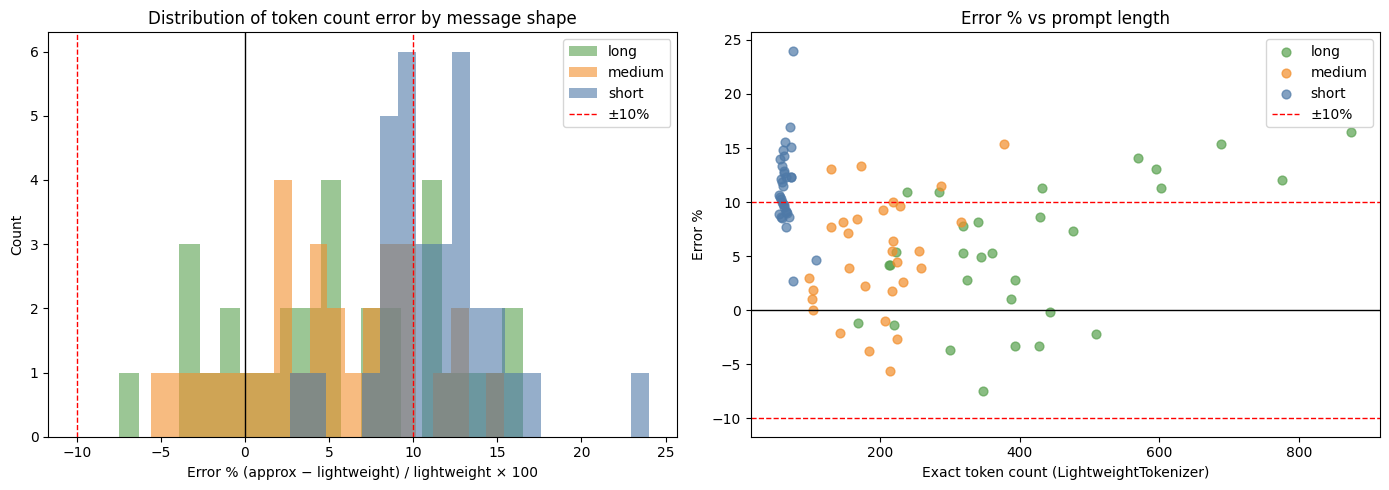

In [8]:
# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Histogram of pct_error by shape ---
ax = axes[0]
colors = {'short': '#4e79a7', 'medium': '#f28e2b', 'long': '#59a14f'}
for shape, grp in df.groupby('shape'):
    ax.hist(grp['pct_error'], bins=20, alpha=0.6, label=shape, color=colors.get(shape))
ax.axvline(0, color='black', linewidth=1)
ax.axvline(-10, color='red', linewidth=1, linestyle='--', label='±10%')
ax.axvline(10, color='red', linewidth=1, linestyle='--')
ax.set_xlabel('Error % (approx − lightweight) / lightweight × 100')
ax.set_ylabel('Count')
ax.set_title('Distribution of token count error by message shape')
ax.legend()

# --- Scatter: token count vs pct_error ---
ax = axes[1]
for shape, grp in df.groupby('shape'):
    ax.scatter(grp['lightweight'], grp['pct_error'], alpha=0.7, label=shape, color=colors.get(shape), s=40)
ax.axhline(0, color='black', linewidth=1)
ax.axhline(-10, color='red', linewidth=1, linestyle='--', label='±10%')
ax.axhline(10, color='red', linewidth=1, linestyle='--')
ax.set_xlabel('Exact token count (LightweightTokenizer)')
ax.set_ylabel('Error %')
ax.set_title('Error % vs prompt length')
ax.legend()

plt.tight_layout()
plt.show()

## Interpretation

`calculate_tokens_used()` in `qa_graph.py` uses the tokenizer to decide how much retrieved context
fits in the prompt before hitting the model's context window. It is a **budget check**, not a billing
measurement (billing uses actual token counts returned by the OpenAI endpoint).

**What the error means in practice:**  
If `count_tokens_approximately` consistently over-estimates (positive error), the system will be
slightly *more conservative* — fitting less context than it could. If it under-estimates, it risks
sending prompts that are marginally over-budget (the model typically handles this gracefully by
truncating).

**Decision heuristic:**  
- p95 error within ±15% → approximation is likely safe for budget decisions  
- Consistent bias in one direction → consider adjusting `chars_per_token` (default 4.0)  
- Error grows with prompt length → be cautious for very long prompts (>3000 tokens)